In [10]:
import warnings
warnings.filterwarnings("ignore")
# to make the output legible and ignore unnecessary warnings.

# Market Basket Analysis
This notebook demonstrates Market Basket Analysis using association rule mining.

Steps:
1. Data preprocessing
2. Product popularity analysis
3. Frequent itemset mining (Apriori & FP-Growth)
4. Association rule generation
5. Network visualization
6. Algorithm comparison

## Install Libraries

In [11]:
!pip install pandas mlxtend networkx matplotlib kagglehub

## Import Libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import time
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import kagglehub

## Download Dataset

In [13]:
path = kagglehub.dataset_download('psparks/instacart-market-basket-analysis')
print(path)

Using Colab cache for faster access to the 'instacart-market-basket-analysis' dataset.
/kaggle/input/instacart-market-basket-analysis


## Load Dataset

In [14]:
import os

for f in os.listdir(path):
    print(f)

df_original = pd.read_csv(os.path.join(path, "order_products__prior.csv"))
df_original.head()

products.csv
order_products__train.csv
orders.csv
order_products__prior.csv
aisles.csv
departments.csv


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [15]:
df = df_original.head(50000)
print(df_original.shape)
print(df.shape)

(32434489, 4)
(50000, 4)


The whole dataset is too big to process at once and hinders with proper execution. Hence, we only use the first 50000 entries which gives us an comfortable enough amount of data.

## Transform Transactions

In [16]:
products_df = pd.read_csv(os.path.join(path, "products.csv"))
df_merged = pd.merge(df, products_df[['product_id', 'product_name']], on='product_id', how='left')

transactions = df_merged.groupby('order_id')['product_name'].apply(list).values.tolist()

print(len(transactions))
transactions[:5]

4978


[['Organic Egg Whites',
  'Michigan Organic Kale',
  'Garlic Powder',
  'Coconut Butter',
  'Natural Sweetener',
  'Carrots',
  'Original Unflavored Gelatine Mix',
  'All Natural No Stir Creamy Almond Butter',
  'Classic Blend Cole Slaw'],
 ['Total 2% with Strawberry Lowfat Greek Strained Yogurt',
  'Unsweetened Almondmilk',
  'Lemons',
  'Organic Baby Spinach',
  'Unsweetened Chocolate Almond Breeze Almond Milk',
  'Organic Ginger Root',
  'Air Chilled Organic Boneless Skinless Chicken Breasts',
  'Organic Ezekiel 49 Bread Cinnamon Raisin'],
 ['Plain Pre-Sliced Bagels',
  'Honey/Lemon Cough Drops',
  'Chewy 25% Low Sugar Chocolate Chip Granola',
  'Oats & Chocolate Chewy Bars',
  "Kellogg's Nutri-Grain Apple Cinnamon Cereal",
  'Nutri-Grain Soft Baked Strawberry Cereal Breakfast Bars',
  "Kellogg's Nutri-Grain Blueberry Cereal",
  'Tiny Twists Pretzels',
  'Traditional Snack Mix',
  'Goldfish Cheddar Baked Snack Crackers',
  'Original Orange Juice',
  'Sugarfree Energy Drink',
  'Ener

We group each transaction. From having individual items in different rows to having a list of all items purchased together.

## One Hot Encoding Basket

In [17]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)
basket.head()

,& Go! Hazelnut Spread + Pretzel Sticks,0 Calorie Strawberry Dragonfruit Water Beverage,0% Fat Blueberry Greek Yogurt,0% Fat Free Organic Milk,0% Fat Organic Greek Vanilla Yogurt,0% Fat Superfruits Greek Yogurt,0% Greek Strained Yogurt,0% Greek Yogurt Black Cherry on the Bottom,"0% Greek, Blueberry on the Bottom Yogurt",0% Milkfat Greek Plain Yogurt,...,gel hand wash sea minerals,in Gravy with Carrots Peas & Corn Mashed Potatoes & Meatloaf Nuggets,of Hanover 100 Calorie Pretzels Mini,of Norwich Original English Mustard Powder Double Superfine,smartwater® Electrolyte Enhanced Water,vitaminwater® XXX Acai Blueberry Pomegranate,with Crispy Almonds Cereal,with Olive Oil Mayonnaise,with Olive Oil Mayonnaise Dressing,with Xylitol Minty Sweet Twist 18 Sticks Sugar Free Gum
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Top Selling Products (EDA)

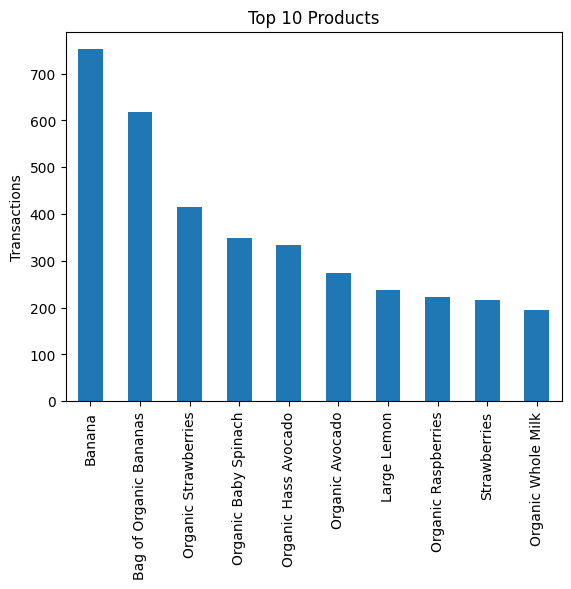

,0
Banana,752
Bag of Organic Bananas,617
Organic Strawberries,416
Organic Baby Spinach,349
Organic Hass Avocado,333
Organic Avocado,275
Large Lemon,238
Organic Raspberries,223
Strawberries,217
Organic Whole Milk,196


In [18]:
top_items = basket.sum().sort_values(ascending=False).head(10)
top_items.plot(kind="bar")
plt.title("Top 10 Products")
plt.ylabel("Transactions")
plt.show()
top_items

## Support Threshold Experiment

In [19]:
support_values = [0.01, 0.005, 0.003, 0.002]

results = []
for s in support_values:
    itemsets = apriori(basket, min_support=s, use_colnames=True)
    results.append({"min_support": s, "num_itemsets": len(itemsets)})

pd.DataFrame(results)

,min_support,num_itemsets
0,0.010,123
1,0.005,360
2,0.003,829
3,0.002,1650


We observe that 0.002 support is the most ideal since it gives the most amount of itemsets using the least amount of resources.

0.002 support equates to itemsets that appear at least 0.2% of the time. In case of 50000 items, it means itemsets that bought more than 100 times.

## Apriori Itemsets

In [20]:
start = time.time()
apriori_itemsets = apriori(basket, min_support=0.002, use_colnames=True)
apriori_time = time.time() - start
print(apriori_time)
apriori_itemsets.head()

74.15688490867615


,support,itemsets
0,0.003616,(0% Greek Strained Yogurt)
1,0.002411,(1% Low Fat Milk)
2,0.003013,(1% Lowfat Milk)
3,0.004419,(100 Calorie Per Bag Popcorn)
4,0.002210,(100% Cranberry Juice)


## FP Growth Itemsets

In [21]:
start = time.time()
fp_itemsets = fpgrowth(basket, min_support=0.002, use_colnames=True)
fp_time = time.time() - start
print(fp_time)
fp_itemsets.head()

14.700002193450928


,support,itemsets
0,0.022901,(Carrots)
1,0.020088,(Michigan Organic Kale)
2,0.007634,(Organic Egg Whites)
3,0.070108,(Organic Baby Spinach)
4,0.013258,(Organic Ginger Root)


## Algorithm Comparison

In [22]:
comparison = pd.DataFrame(
    {
        "Algorithm": ["Apriori", "FP-Growth"],
        "Execution Time": [apriori_time, fp_time],
        "Itemsets": [len(apriori_itemsets), len(fp_itemsets)],
    }
)

comparison

,Algorithm,Execution Time,Itemsets
0,Apriori,74.156885,1650
1,FP-Growth,14.700002,1650


FP-Growth is much faster compared to Apriori while dealing with bigger datasets.

## Association Rules

In [23]:
rules = association_rules(apriori_itemsets, metric="lift", min_threshold=1)
print(rules.shape)
rules.sort_values("confidence", ascending=False).head(10)

(1606, 14)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1420,"(Organic Cucumber, Organic Raspberries)",(Bag of Organic Bananas),0.003415,0.123945,0.002411,0.705882,5.695109,1.0,0.001987,2.978586,0.827236,0.019293,0.664270,0.362666
1504,"(Organic Avocado, Honeycrisp Apple)",(Banana),0.003415,0.151065,0.002411,0.705882,4.672716,1.0,0.001895,2.886380,0.788685,0.015852,0.653545,0.360920
1510,"(Strawberries, Honeycrisp Apple)",(Banana),0.003415,0.151065,0.002411,0.705882,4.672716,1.0,0.001895,2.886380,0.788685,0.015852,0.653545,0.360920
1444,"(Organic Raspberries, Organic Hass Avocado)",(Bag of Organic Bananas),0.008035,0.123945,0.004821,0.600000,4.840843,1.0,0.003825,2.190137,0.799851,0.037915,0.543407,0.319449
1571,"(Organic Cilantro, Organic Strawberries)",(Banana),0.003415,0.151065,0.002009,0.588235,3.893930,1.0,0.001493,2.061700,0.745737,0.013175,0.514963,0.300767
18,(Almond Breeze Original Almond Milk),(Banana),0.004219,0.151065,0.002411,0.571429,3.782675,1.0,0.001773,1.980849,0.738753,0.015769,0.495166,0.293693
1372,"(Organic Yellow Onion, Carrots)",(Bag of Organic Bananas),0.003616,0.123945,0.002009,0.555556,4.482262,1.0,0.001561,1.971123,0.779718,0.016000,0.492675,0.285882
1480,"(Organic Yellow Onion, Organic Small Bunch Cel...",(Bag of Organic Bananas),0.004018,0.123945,0.002210,0.550000,4.437439,1.0,0.001712,1.946788,0.777770,0.017572,0.486333,0.283914
402,(Raspberry Preserves),(Banana),0.003817,0.151065,0.002009,0.526316,3.484043,1.0,0.001432,1.792197,0.715709,0.013141,0.442026,0.269807
1456,"(Organic Tomato Cluster, Organic Hass Avocado)",(Bag of Organic Bananas),0.003817,0.123945,0.002009,0.526316,4.246353,1.0,0.001536,1.849449,0.767433,0.015974,0.459298,0.271262


We find ~1600 rules that have a lift of greater than 1.0
## Rule Filtering Criteria

To ensure that only meaningful product relationships were analyzed, association rules were filtered using the following thresholds:

* **Minimum Support:** 0.002
  Ensures the rule appears in a sufficient number of transactions.

* **Minimum Confidence:** 0.50
  Indicates that the consequent item is purchased at least **50% of the time** when the antecedent items appear.

* **Minimum Lift:** 1.20
  Filters out relationships caused purely by product popularity.
  A lift greater than 1 indicates a **positive association** between products.

After applying these thresholds, **17 high-quality rules** remained and were used for visualization and business interpretation.

## Filter Strong Rules

In [24]:
rules_filtered = rules[(rules["confidence"] >= 0.5) & (rules["lift"] > 1.2)]
print(rules_filtered.shape)
rules_filtered.sort_values("lift", ascending=False).head(10)

(17, 14)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1420,"(Organic Cucumber, Organic Raspberries)",(Bag of Organic Bananas),0.003415,0.123945,0.002411,0.705882,5.695109,1.0,0.001987,2.978586,0.827236,0.019293,0.664270,0.362666
1444,"(Organic Raspberries, Organic Hass Avocado)",(Bag of Organic Bananas),0.008035,0.123945,0.004821,0.600000,4.840843,1.0,0.003825,2.190137,0.799851,0.037915,0.543407,0.319449
1510,"(Strawberries, Honeycrisp Apple)",(Banana),0.003415,0.151065,0.002411,0.705882,4.672716,1.0,0.001895,2.886380,0.788685,0.015852,0.653545,0.360920
1504,"(Organic Avocado, Honeycrisp Apple)",(Banana),0.003415,0.151065,0.002411,0.705882,4.672716,1.0,0.001895,2.886380,0.788685,0.015852,0.653545,0.360920
1372,"(Organic Yellow Onion, Carrots)",(Bag of Organic Bananas),0.003616,0.123945,0.002009,0.555556,4.482262,1.0,0.001561,1.971123,0.779718,0.016000,0.492675,0.285882
1480,"(Organic Yellow Onion, Organic Small Bunch Cel...",(Bag of Organic Bananas),0.004018,0.123945,0.002210,0.550000,4.437439,1.0,0.001712,1.946788,0.777770,0.017572,0.486333,0.283914
1456,"(Organic Tomato Cluster, Organic Hass Avocado)",(Bag of Organic Bananas),0.003817,0.123945,0.002009,0.526316,4.246353,1.0,0.001536,1.849449,0.767433,0.015974,0.459298,0.271262
1462,"(Organic Yellow Onion, Organic Hass Avocado)",(Bag of Organic Bananas),0.004821,0.123945,0.002411,0.500000,4.034036,1.0,0.001813,1.752109,0.755753,0.019078,0.429259,0.259724
182,(Organic Salted Butter),(Bag of Organic Bananas),0.004821,0.123945,0.002411,0.500000,4.034036,1.0,0.001813,1.752109,0.755753,0.019078,0.429259,0.259724
1408,"(Organic Cilantro, Organic Hass Avocado)",(Bag of Organic Bananas),0.004018,0.123945,0.002009,0.500000,4.034036,1.0,0.001511,1.752109,0.755143,0.015949,0.429259,0.258104


From ~1600 we select the strongest ones, resulting in 17 rules that meet our criteria of 0.5 confidence & 1.2 lift. In simple terms, itemsets that are bought together more than 50% of the time.

## Network Graph

*Only the top 15 rules ranked by lift were visualized to maintain clarity in the network graph.*


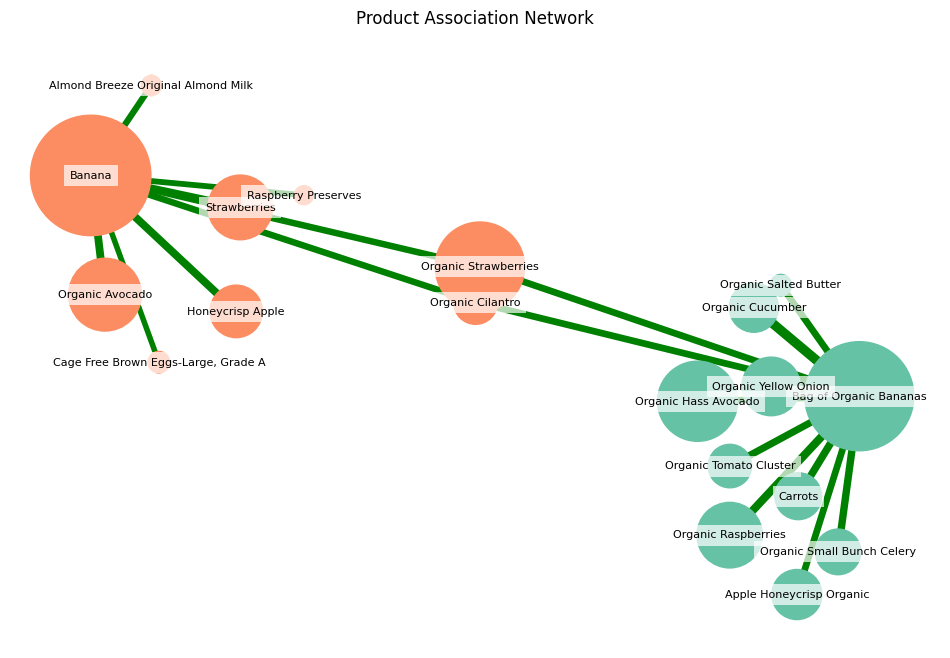

In [25]:
G = nx.DiGraph()
top_rules = rules_filtered.sort_values("lift", ascending=False).head(15)

for _, row in top_rules.iterrows():
    for a in row["antecedents"]:
        for c in row["consequents"]:
            G.add_edge(a, c, weight=row["lift"])

communities = greedy_modularity_communities(G)
communities = [list(c) for c in communities]

color_map = {}
colors = cm.Set2(range(len(communities)))

for color, community in zip(colors, communities):
    for node in community:
        color_map[node] = color

node_colors = [color_map[node] for node in G.nodes()]

pos = nx.spring_layout(G, k=1.4, iterations=120, seed=42)

node_sizes = [basket[node].sum() * 10 for node in G.nodes()]
edge_widths = [G[u][v]["weight"] * 1.2 for u, v in G.edges()]

plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    arrows=False,
    edge_color='green'
)

plt.title("Product Association Network")
plt.axis("off")
plt.show()

Product Association Network Visualization

To better interpret the association rules, the relationships between products are visualized using a network graph.

In this graph:

* Nodes represent products.

* Node size corresponds to product popularity, based on how frequently the item appears in transactions.

* Edges represent association rules between products.

* Edge thickness reflects the strength of the relationship, based on the Lift value.

* Node colors represent communities (clusters) detected using graph community detection algorithms.

This visualization reveals natural product clusters that are frequently purchased together.

Two dominant clusters emerge:

1. Fruit / Snack Cluster:
Items such as Banana, Strawberries, Honeycrisp Apple, Organic Avocado, and Almond Milk form a strong cluster, indicating common purchasing behavior around fresh fruit and breakfast/snack items.

2. Organic Produce Cluster:
Products like Bag of Organic Bananas, Organic Hass Avocado, Organic Tomato Cluster, Organic Yellow Onion, Organic Celery, and Organic Raspberries form another dense cluster, suggesting that customers who purchase organic produce tend to buy multiple organic items together.

The visualization helps stakeholders quickly identify product ecosystems that can inform store layout decisions and recommendation systems.

In [26]:
plt.savefig("product_association_network.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Save the graph.

## Conclusion
This project applied **Market Basket Analysis (MBA)** techniques to uncover hidden relationships within retail transaction data.

Using **Apriori and Association Rule Mining**, frequent itemsets were identified and evaluated using the key metrics **Support, Confidence, and Lift**. After filtering the results for high-confidence and high-lift rules, several meaningful product associations were discovered.

The strongest rules reveal that:

* Customers purchasing combinations of **organic produce items** (such as Organic Cucumbers, Organic Raspberries, Organic Hass Avocados, and Organic Onions) are highly likely to also purchase **Bag of Organic Bananas.**

* Similarly, combinations of **fruit items** such as *Strawberries and Honeycrisp Apples* show a strong association with **Bananas**.

* These results indicate that bananas—especially organic bananas—act as **central hub products** in many shopping baskets.

The **network visualization** further highlights two major purchasing clusters:

* A **fruit and snack cluster** centered around bananas.

* An **organic produce cluster** centered around organic bananas and related vegetables.

From a business perspective, these insights can be leveraged in several ways:

1. **Store Layout Optimization:** Place frequently associated products closer together to encourage bundled purchases.

2. **Cross-Selling Recommendations:** Online stores can recommend items like organic avocados or raspberries when customers add organic bananas to their cart.

3. **Bundle Promotions:** Retailers could create promotional bundles combining organic bananas with commonly associated organic produce items.

Overall, the analysis demonstrates how **data-driven association mining can provide actionable insights** that improve product placement, recommendation systems, and marketing strategies, ultimately increasing the **Average Order Value (AOV)**.